# Reading `tech_comparison` — a guided tour for coauthors

**Who this is for.** Anyone on the paper who wants to understand what the
technology-comparison analysis (`tech_comparison.ipynb`) actually shows, without wading
through its engine code or its statistics. It assumes no modeling background. If you know
ReEDS but not Monte Carlo, or economics but not nuclear cost modeling, or policy but
neither — there is an on-ramp here for you, and a glossary at the end (§19).

**What this notebook is.** A *reader*, not a model. Every number and figure here is
loaded from the production notebook's exported results (`exports/tech_comparison/`);
nothing is recomputed. Where a concept needs a picture that isn't a result — a toy
learning curve, a two-lottery example — the figure is stamped
**ILLUSTRATION — not model output** in its title, so a screenshot can never be mistaken
for a finding. Every real figure carries a small "reads: …" line naming the export file
it was drawn from.

**How to read it.** Four parts: **I. The Question** (what choice is being analyzed),
**II. The Machinery** (how the analysis works — six ideas, one section each),
**III. The Results** (a walk down the pre-registered claims ledger, C1–C7, one claim per
section), **IV. Wrap** (what to take away, glossary). Sections are self-contained enough
to jump around, but Part II's §7 (the coupling dial κ) is the one piece of machinery
everything downstream leans on.

In [1]:
# Setup: paths, house style, small helpers. (All data loading is read-only.)
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = "plotly_mimetype+notebook"   # embeds plotly.js -> survives HTML export

NB_DIR = Path.cwd() if Path.cwd().name == "mc" else Path("z-ethan/mc").resolve()
REPO_ROOT = NB_DIR.parent.parent
TCX = NB_DIR / "exports" / "tech_comparison"
PERDRAW = TCX / "perdraw"
assert TCX.exists() and PERDRAW.exists(), \
    "exports/tech_comparison not found - run tech_comparison.ipynb first"
FIGURES = NB_DIR / "figures"

# --- house figure style: z-ethan/plotstyle.py is the normative standard ---
sys.path.insert(0, str(NB_DIR.parent))   # z-ethan/ (robust to cwd = mc/ or repo root)
import plotstyle as ps
ps.apply()
COL = ps.COL
INK, MUTED, FAINT, GRID_C, EDGE_C, SURFACE = (ps.INK, ps.MUTED, ps.FAINT,
                                              ps.GRID_C, ps.EDGE_C, ps.SURFACE)
AMBER, RED, GREEN = ps.ACCENT["gold"], ps.ACCENT["red"], ps.ACCENT["green"]
CMAP_DIV = ps.cmap_div()

def provenance(fig, files):
    """Stamp a figure with the export file(s) it was drawn from."""
    fig.text(0.99, 0.005, f"reads: {files}", ha="right", va="bottom",
             fontsize=7, color=FAINT, style="italic")

def illustration(ax, title):
    """Title a toy figure so it can never pass for a result."""
    ax.set_title(f"ILLUSTRATION — not model output\n{title}", fontsize=10, color=AMBER)

# --- the production run's exports ---
ROB = pd.read_csv(TCX / "robustness_map.csv")
LEDGER = pd.read_csv(TCX / "claims_ledger.csv", index_col=0)
META = json.loads((TCX / "tc_metadata.json").read_text())
LARGEWIN = pd.read_csv(TCX / "large_win_margins.csv")
EXANTE = pd.read_csv(TCX / "exante_ranking.csv")
DOM = pd.read_csv(TCX / "dominance_tests.csv")
ADAPT = pd.read_csv(TCX / "adaptive_value.csv")
EVPI_TOT = pd.read_csv(TCX / "evpi_total.csv")
EVPI_PART = pd.read_csv(TCX / "evpi_partial.csv")
STRESS = pd.read_csv(TCX / "stress_survival.csv")

TOKEN_NAME = {"eia_aeo_high": "EIA 2026 AEO high", "abou_jaoude": "Abou-Jaoude mod",
              "iaea_high": "IAEA high", "mckinsey": "McKinsey GEP 2025",
              "cop28": "COP28 tripling pledge", "eo2025": "2025 EO"}
SCHED_ORDER = list(TOKEN_NAME.values())              # ascending 2050 ambition
SCHED_SHORT = {"EIA 2026 AEO high": "EIA\nAEO high", "Abou-Jaoude mod": "Abou-\nJaoude",
               "IAEA high": "IAEA\nhigh", "McKinsey GEP 2025": "McKinsey",
               "COP28 tripling pledge": "COP28", "2025 EO": "2025 EO"}
SCHED_COLORS = {s: plt.cm.Greens(x) for s, x in
                zip(SCHED_ORDER, np.linspace(0.45, 0.95, len(SCHED_ORDER)))}
KAPPA_CELLS = {"k100": 1.0, "k075": 0.75, "k050": 0.5, "k025": 0.25, "k000": 0.0}
CELL_LABEL = {"k100": "κ = 1  (the old assumption)", "k075": "κ = 0.75", "k050": "κ = 0.5",
              "k025": "κ = 0.25", "k000": "κ = 0  (independent)",
              "probe_lr0_boak1": "probe: price tags coupled, learning independent",
              "probe_lr1_boak0": "probe: learning coupled, price tags independent"}
CELL_ORDER = list(CELL_LABEL)

def load_perdraw(cell, token):
    """One (dependence cell, schedule) per-draw file -> dict of aligned arrays."""
    z = np.load(PERDRAW / f"{cell}_{token}.npz", allow_pickle=False)
    cols = [str(c) for c in z["columns"]]
    w = pd.DataFrame(z["world"], columns=cols)
    return {"world": w, "R_large": z["R_npv_large"], "R_smr": z["R_npv_smr"],
            "winner": z["winner"].astype(str), "m_pct": z["m_pct"]}

def as_bn(r):
    """Program NPV in internal units (2022$/kW x GW, discounted to 2030) -> billion 2022$."""
    return r / 1e3

print(f"loaded exports from run of {META['generated_utc']} "
      f"(git {META['fork_git_head'][:8]}, seed {META['master_seed']}); "
      f"{len(ROB)} robustness-map rows, {len(LEDGER)} claims")

loaded exports from run of 2026-08-07T19:21:39+00:00 (git afba700d, seed 20260715); 60 robustness-map rows, 7 claims


## Part I — The Question

### §1 · The bet, in one picture

The United States has committed, in several official and semi-official scenarios, to a
large build-out of nuclear power between 2031 and 2050. Two technologies could carry it:

- **Traditional large reactors** (~1,000 MW each, like Vogtle): a proven machine with a
  *known-ish* price — expensive, but we have receipts.
- **Small modular reactors (SMRs)** (~300 MW each): a newer design that starts *more*
  expensive per kilowatt, but — because each plant is smaller, factory-built, and
  repeated many more times — is expected to get cheaper faster as units accumulate.

That is the entire tension, and it needs only two vocabulary words:

- **Anchor cost** — the price per kilowatt of the units built at the start of the
  program (2030), before any new learning. The sticker price.
- **Learning rate** — the percentage the price drops every time cumulative built units
  *double*. Faster learning ⇒ a steeper downhill slide.

The SMR proposition is: *pay more at the start, slide downhill faster*. Whether that
trade wins depends on how big the head start is, how much faster the slide is, and how
many units the program builds. The figure below is a cartoon of the two paths.

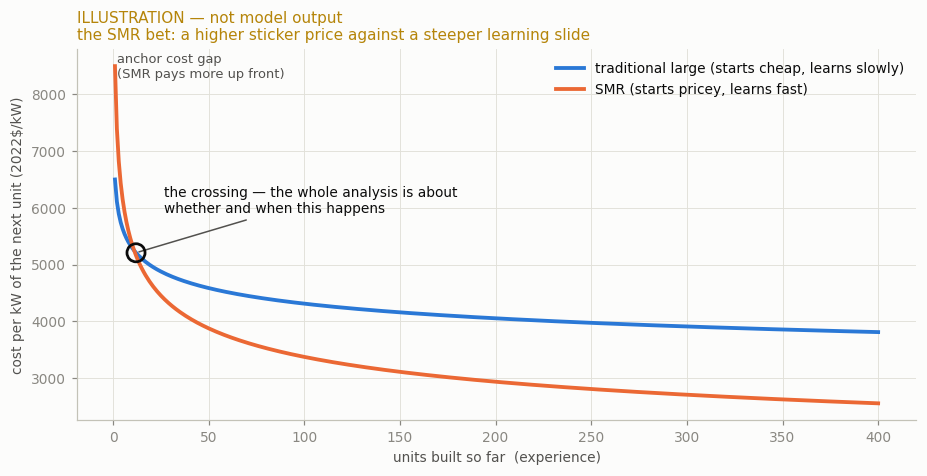

In [2]:
# §1 figure - the bet as two toy cost curves (ILLUSTRATION).
n = np.arange(1, 401)
lr_large, lr_smr = 0.06, 0.13
c_large = 6500 * n ** np.log2(1 - lr_large)
c_smr = 8500 * (n * 3.33) ** np.log2(1 - lr_smr) / (3.33 ** np.log2(1 - lr_smr))
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(n, c_large, color=COL["large"], lw=2.5, label="traditional large (starts cheap, learns slowly)")
ax.plot(n, c_smr, color=COL["smr"], lw=2.5, label="SMR (starts pricey, learns fast)")
ix = int(np.argmax(c_smr < c_large))
ax.scatter([n[ix]], [c_large[ix]], s=140, facecolor="none", edgecolor=INK, lw=1.8, zorder=5)
ax.annotate("the crossing — the whole analysis is about\nwhether and when this happens",
            (n[ix], c_large[ix]), textcoords="offset points", xytext=(18, 26),
            fontsize=9, color=INK, arrowprops=dict(arrowstyle="-", color=MUTED, lw=1))
ax.annotate("anchor cost gap\n(SMR pays more up front)", (2, 8300), fontsize=8.5, color=MUTED)
ax.set_xlabel("units built so far  (experience)")
ax.set_ylabel("cost per kW of the next unit (2022$/kW)")
illustration(ax, "the SMR bet: a higher sticker price against a steeper learning slide")
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()
plt.show()

### §2 · The program, not the plant

The analysis never prices a single reactor. It prices a **whole build program**: a
mandated schedule of gigawatts to be added each year, 2031–2050. Six such schedules are
studied, drawn from real published projections and pledges, ordered from least to most
ambitious:

| Schedule | Real-world source | Rough 2050 build |
|---|---|---|
| EIA 2026 AEO high | US Energy Information Administration, high-nuclear projection | smallest |
| Abou-Jaoude mod | INL cost study's moderate deployment case | ↓ |
| IAEA high | IAEA's high global-growth case, US share | ↓ |
| McKinsey GEP 2025 | McKinsey Global Energy Perspective | ↓ |
| COP28 tripling pledge | The "triple nuclear by 2050" pledge, US share | ↓ |
| 2025 EO | The 2025 Executive Order's 400 GW target | largest |

Think of it as costing **the whole grocery run, not one item**: policy has already
written the shopping list (the schedule); the only question the analysis answers is
*which brand fills the cart* — and what the cart costs under each choice.

One piece of discipline is planted here and never relaxed: **every number downstream is
conditional on the schedule being built.** The analysis never asks whether a schedule is
achievable or wise — that is a different (important) question that lives outside this
model. More ambitious schedules build more units, so learning compounds harder; you will
see that pattern in every results figure.

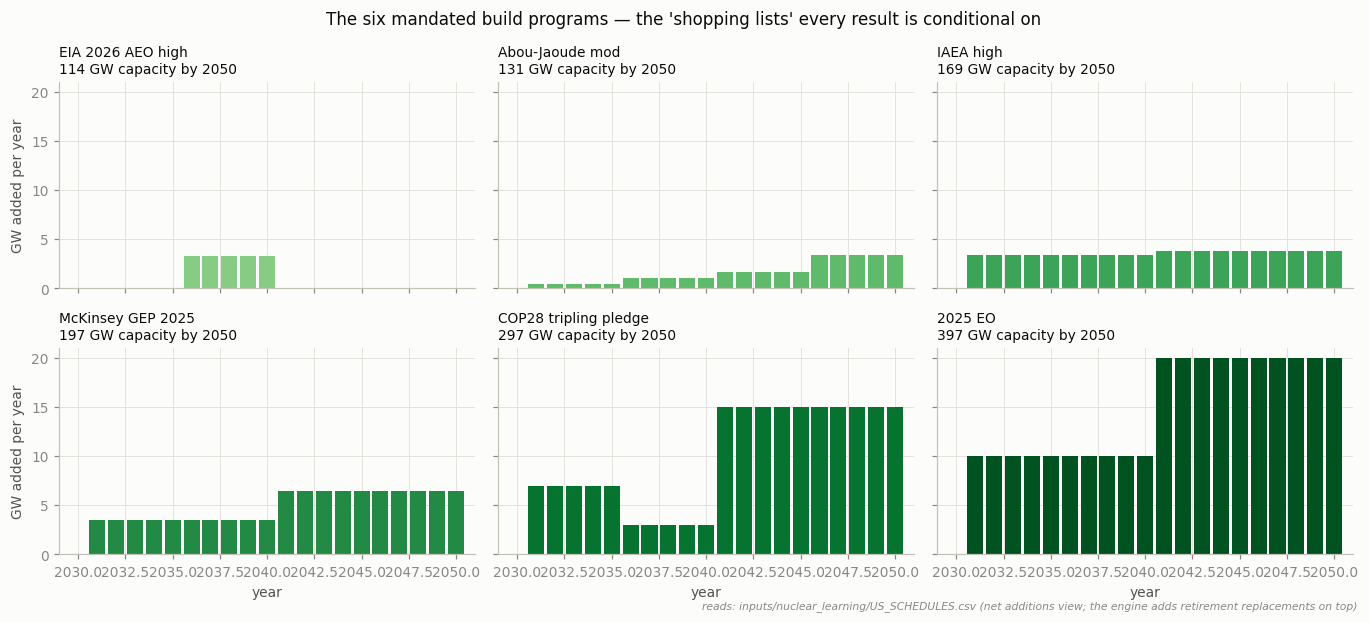

In [3]:
# §2 figure - the six mandated build schedules (GW added per year), from the single
# source of truth the production engine itself reads.
_sched_df = pd.read_csv(REPO_ROOT / "inputs" / "nuclear_learning" / "US_SCHEDULES.csv",
                        comment="#", index_col="year")
YEARS = _sched_df.index.to_numpy()
fig, axes = plt.subplots(2, 3, figsize=(12.5, 5.6), sharex=True, sharey=True)
for ax, (tok, name) in zip(axes.ravel(), TOKEN_NAME.items()):
    cap = _sched_df[tok].to_numpy(float) - 3.0          # working GW basis (house convention)
    add = np.clip(np.diff(cap, prepend=cap[0]), 0, None)
    add[YEARS <= 2030] = 0.0
    ax.bar(YEARS, add, color=SCHED_COLORS[name], width=0.85)
    ax.set_title(f"{name}\n{cap[-1]:.0f} GW capacity by 2050", fontsize=9)
    ax.set_xlim(2029, 2051)
for ax in axes[1]:
    ax.set_xlabel("year")
for ax in axes[:, 0]:
    ax.set_ylabel("GW added per year")
fig.suptitle("The six mandated build programs — the 'shopping lists' every result is "
             "conditional on", fontsize=11)
provenance(fig, "inputs/nuclear_learning/US_SCHEDULES.csv (net additions view; the engine "
                "adds retirement replacements on top)")
fig.tight_layout()
plt.show()

### §3 · Rules of the road — what these numbers can and cannot say

Three corrections, stated **before** any result, because each is a natural misreading:

> **1. "P(SMR wins)" is not a forecast that SMRs will be built.** It answers: *in what
> share of the plausible cost-futures we simulated does the SMR program end up cheaper —
> given that the mandated schedule happens?* It is silent on politics, licensing,
> siting, supply chains, and demand.
>
> **2. The probabilities measure our uncertainty about costs, not the frequencies of
> possible worlds.** We do not know what an SMR fleet will cost; we draw thousands of
> cost-futures spanning the published evidence and count outcomes. Change the evidence
> ranges and the probabilities change — §16 shows exactly how much.
>
> **3. "NOT SUPPORTED" verdicts (you will see five of them) are findings, not
> failures.** The claims were written down and thresholds fixed *before* the analysis
> ran (§9). When a pre-registered claim fails, the way it fails is usually the most
> informative result in the study — and it cannot be quietly rewritten after the fact.

## Part II — The Machinery

### §4 · Anatomy of one drawn world

We do not know what either technology will cost. So the analysis rolls **labeled dice**:
for each uncertain input it draws a value from a range grounded in published evidence,
and one complete set of draws — both anchor costs, both learning rates, construction
durations, how much international building teaches US vendors, and so on — is one
**"world"**: a fully specified parallel universe in which both programs can be priced
and compared. The production run holds **10,000 worlds for every (coupling setting ×
schedule)** and keeps score across them.

Below is one real world from the production run, rendered as a trading card. Two things
to notice:

- Everything on the card is *internally consistent* — the same universe's SMR anchor,
  SMR learning rate, financing conditions, and operating costs. Within one technology,
  all of its cost dials share one "luck knob": a world where the SMR is expensive to
  *build* is also a world where it is expensive to *run* (in the jargon of the
  production notebook, O&M "rides the same percentile"). That deliberately avoids
  Frankenstein worlds that are optimistic about one line item and pessimistic about the
  next for no reason.
- The bottom line is a complete horse race: both programs priced on the *same* schedule
  in the *same* world, a winner, and a margin.

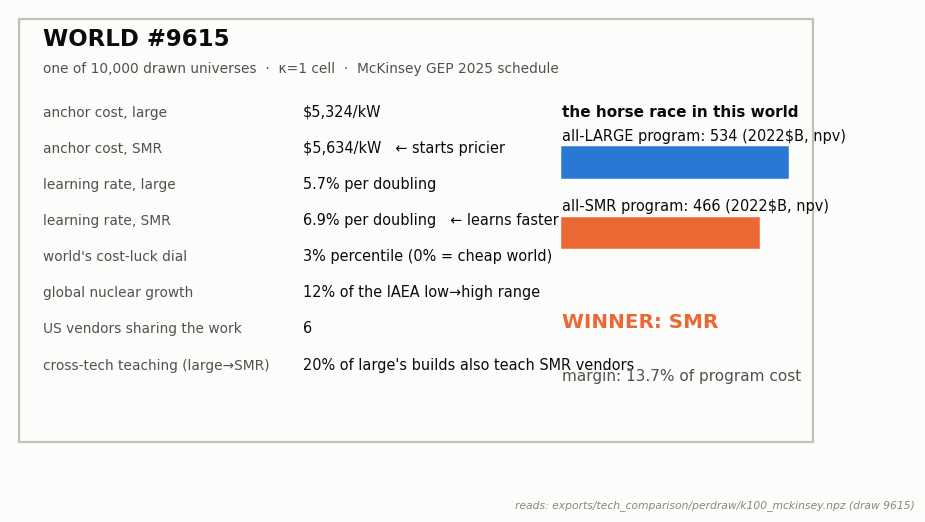

The score across all 10,000 worlds of this cell: SMR wins 87% of them. Everything in Part III is built from counts and distributions like this one.


In [4]:
# §4 - one real drawn world as a trading card (kappa=1 cell, McKinsey schedule).
REP_TOKEN, REP_SCHED = "mckinsey", "McKinsey GEP 2025"
PD_REP = load_perdraw("k100", REP_TOKEN)
_w = PD_REP["world"]
_sw = np.where(PD_REP["winner"] == "smr")[0]
CARD_I = int(_sw[np.argsort(np.abs(PD_REP["m_pct"][_sw]
                                   - np.median(PD_REP["m_pct"][_sw])))[0]])
row = _w.iloc[CARD_I]

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.set_axis_off()
ax.add_patch(plt.Rectangle((0.01, 0.02), 0.98, 0.96, fill=False, ec=EDGE_C, lw=1.5,
                           transform=ax.transAxes))
ax.text(0.04, 0.92, f"WORLD #{CARD_I}", transform=ax.transAxes, fontsize=15,
        color=INK, weight="bold")
ax.text(0.04, 0.86, f"one of 10,000 drawn universes  ·  κ=1 cell  ·  {REP_SCHED} schedule",
        transform=ax.transAxes, fontsize=9, color=MUTED)
left = [
    ("anchor cost, large", f"${row['boak_large']:,.0f}/kW"),
    ("anchor cost, SMR", f"${row['boak_smr']:,.0f}/kW   ← starts pricier"),
    ("learning rate, large", f"{row['lr_large']:.1%} per doubling"),
    ("learning rate, SMR", f"{row['lr_smr']:.1%} per doubling   ← learns faster"),
    ("world's cost-luck dial", f"{row['u_boak_large']:.0%} percentile (0% = cheap world)"),
    ("global nuclear growth", f"{row['u']:.0%} of the IAEA low→high range"),
    ("US vendors sharing the work", f"{int(row['n_vendors'])}"),
    ("cross-tech teaching (large→SMR)", f"{row['x_ls']:.0%} of large's builds also teach SMR vendors"),
]
for j, (k, v) in enumerate(left):
    y = 0.76 - 0.082*j
    ax.text(0.04, y, k, transform=ax.transAxes, fontsize=9, color=MUTED)
    ax.text(0.36, y, v, transform=ax.transAxes, fontsize=9.5, color=INK)
Rl, Rs = as_bn(PD_REP["R_large"][CARD_I]), as_bn(PD_REP["R_smr"][CARD_I])
ax.text(0.68, 0.76, "the horse race in this world", transform=ax.transAxes, fontsize=10,
        color=INK, weight="bold")
for j, (tech, val) in enumerate([("large", Rl), ("smr", Rs)]):
    y = 0.62 - 0.16*j
    ax.add_patch(plt.Rectangle((0.68, y), 0.28*val/max(Rl, Rs), 0.07,
                               color=COL[tech], transform=ax.transAxes))
    ax.text(0.68, y + 0.085, f"all-{tech.upper()} program: {val:,.0f} (2022$B, npv)",
            transform=ax.transAxes, fontsize=9.5, color=INK)
ax.text(0.68, 0.28, f"WINNER: {PD_REP['winner'][CARD_I].upper()}",
        transform=ax.transAxes, fontsize=13, weight="bold",
        color=COL[PD_REP["winner"][CARD_I]])
ax.text(0.68, 0.16, f"margin: {abs(PD_REP['m_pct'][CARD_I]):.1f}% of program cost",
        transform=ax.transAxes, fontsize=10, color=MUTED)
provenance(fig, f"exports/tech_comparison/perdraw/k100_{REP_TOKEN}.npz (draw {CARD_I})")
plt.show()
print(f"The score across all 10,000 worlds of this cell: SMR wins "
      f"{(PD_REP['winner'] == 'smr').mean():.0%} of them. Everything in Part III is "
      "built from counts and distributions like this one.")

### §5 · Learning curves: the engine under the hood

The one mechanism doing nearly all the work: **every time the cumulative number of units
built doubles, cost per kW falls by a fixed percentage** — the learning rate. This is the
same empirical regularity that took solar panels from luxury hardware to the cheapest
electricity in history; nuclear's own record on it is mixed, which is exactly why the
learning rate is drawn from a range rather than assumed.

Two consequences matter for intuition:

1. **Doublings come fast when you start from (near) zero and never when you start from
   hundreds.** An SMR fleet's 4th, 8th, 16th unit arrive within a few years — three
   doublings. The US large-reactor enterprise, with ~140 units of history behind it,
   would need ~140 *more* to double once. Small and new ⇒ steep territory of the curve.
2. **Where you start counting moves the whole curve.** Does the SMR industry inherit
   credit for decades of large-reactor experience, or start its count near zero? This
   "experience base" convention is itself uncertain — the analysis draws it — and it
   resurfaces as one of the decision-relevant unknowns in §15.

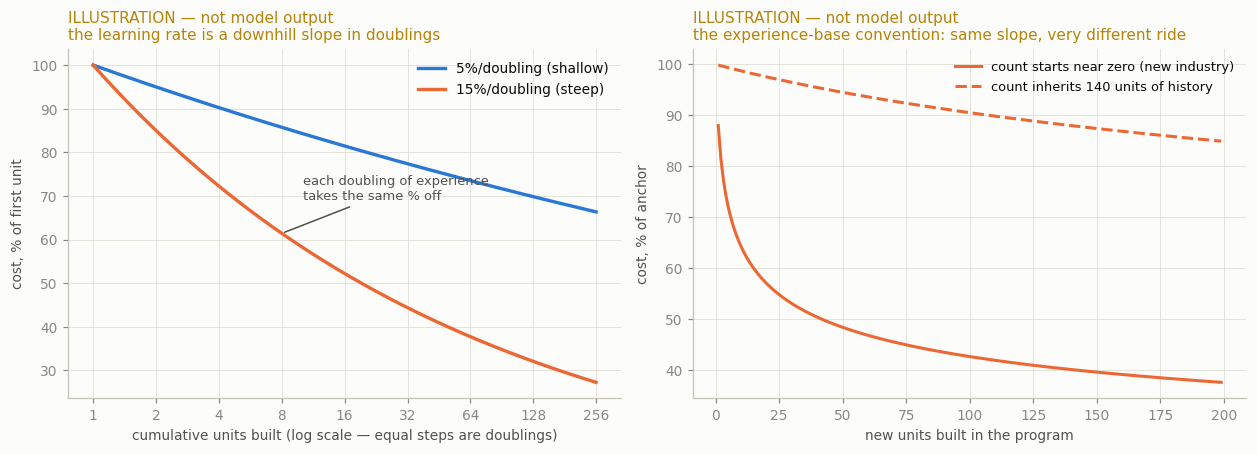

In [5]:
# §5 figure - learning rates as downhill slopes (ILLUSTRATION).
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
n = 2 ** np.linspace(0, 8, 200)
ax = axes[0]
for lr, c, lbl in [(0.05, COL["large"], "5%/doubling (shallow)"),
                   (0.15, COL["smr"], "15%/doubling (steep)")]:
    ax.plot(n, 100 * n ** np.log2(1 - lr), color=c, lw=2.2, label=lbl)
ax.set_xscale("log", base=2)
ax.set_xticks([1, 2, 4, 8, 16, 32, 64, 128, 256])
ax.set_xticklabels([1, 2, 4, 8, 16, 32, 64, 128, 256])
ax.annotate("each doubling of experience\ntakes the same % off",
            (8, 100 * 8 ** np.log2(0.85)), textcoords="offset points", xytext=(14, 22),
            fontsize=8.5, color=MUTED, arrowprops=dict(arrowstyle="-", color=MUTED, lw=1))
ax.set_xlabel("cumulative units built (log scale — equal steps are doublings)")
ax.set_ylabel("cost, % of first unit")
illustration(ax, "the learning rate is a downhill slope in doublings")
ax.legend(fontsize=9)
ax = axes[1]
for base, ls, lbl in [(1, "-", "count starts near zero (new industry)"),
                      (140, "--", "count inherits 140 units of history")]:
    ax.plot(np.arange(1, 200), 100 * ((base + np.arange(1, 200))/base) ** np.log2(0.88),
            color=COL["smr"], lw=2, ls=ls, label=lbl)
ax.set_xlabel("new units built in the program")
ax.set_ylabel("cost, % of anchor")
illustration(ax, "the experience-base convention: same slope, very different ride")
ax.legend(fontsize=8.5)
fig.tight_layout()
plt.show()

### §6 · Pricing a program — and how this relates to ReEDS

In each world, each program's price tag is a single number: the **program NPV** — every
year's construction spending (marked up for financing and interest during construction)
plus the 30-year present value of operating costs (fixed O&M, variable O&M, fuel) for
each kilowatt built, all **discounted to 2030** at ReEDS's own real discount rate. A
dollar spent in 2045 counts for less than a dollar spent in 2032 — the familiar
time-machine price tag. The figure shows that construction for the §4 world: the raw
yearly bills, and the same bills after discounting.

> **Sidebar for the ReEDS reader.** In ReEDS, the model *chooses* what to build,
> year by year, weighing capital cost against system value — dispatch, transmission,
> capacity value, flexibility. Here the build path is **fixed by mandate**; only the
> technology label varies, and the objective is the capex + O&M + fuel + financing slice
> of what would be ReEDS's objective, with all system-value feedbacks deliberately
> stripped out. That stripping is a *feature* (a clean apples-to-apples cost race — the
> learning feedback would otherwise let ReEDS double-count experience) and a
> *limitation* (no credit for SMR's greater dispatch flexibility; a bounding
> "flexibility credit" stress in §16 checks that this omission is not decisive). The
> financing math itself — construction-schedule interest, tax/depreciation multipliers,
> 30-year evaluation window — is a verbatim replication of ReEDS's, pinned bit-for-bit
> in the production notebook's QA suite.

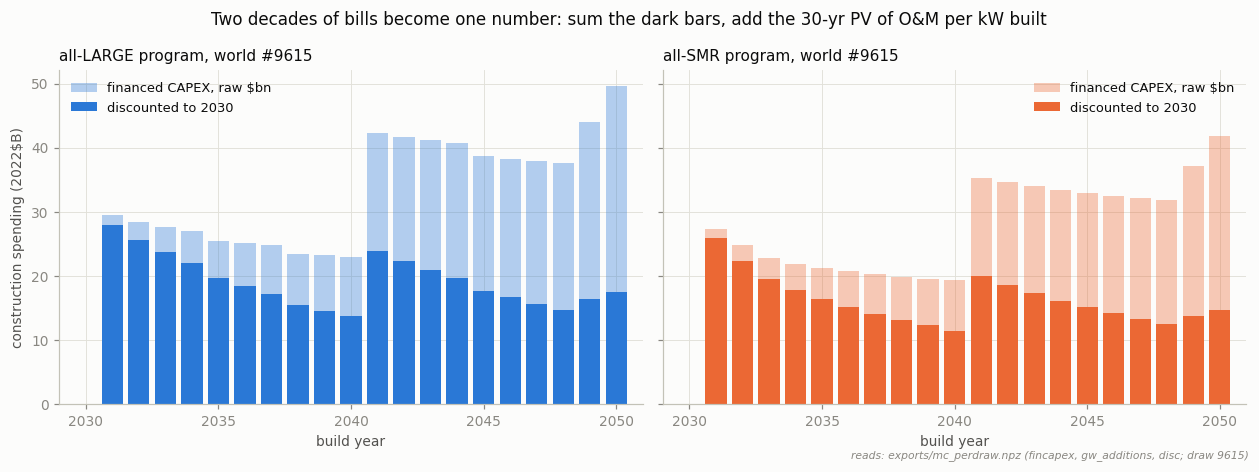

Note the shape: the SMR program's bars start taller (pricier anchor) and flatten or fall as learning compounds; the large program's stay steadier. Discounting shrinks late-decade bars the most - which slightly favors the technology that is cheap EARLY, i.e. it leans against SMR.


In [6]:
# §6 figure - the same world's construction bills, raw and discounted (real trajectories
# from the companion MC's per-draw export; the kappa=1 worlds ARE its worlds, same order).
MCZ = np.load(NB_DIR / "exports" / "mc_perdraw.npz", allow_pickle=False)
_years = MCZ["years"]
_gw = MCZ[f"gw_additions_{REP_TOKEN}"]
_disc = MCZ["disc"]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
for ax, tech in zip(axes, ["large", "smr"]):
    spend = MCZ[f"fincapex_{REP_TOKEN}_{tech}"][CARD_I] * _gw / 1e3   # $bn per build year
    ax.bar(_years, spend, color=COL[tech], alpha=0.35, width=0.8,
           label="financed CAPEX, raw $bn")
    ax.bar(_years, spend / _disc, color=COL[tech], width=0.8,
           label="discounted to 2030")
    ax.set_title(f"all-{tech.upper()} program, world #{CARD_I}", fontsize=10)
    ax.set_xlabel("build year")
    ax.set_xlim(2029, 2051)
    ax.set_xticks([2030, 2035, 2040, 2045, 2050])
    ax.legend(fontsize=8.5)
axes[0].set_ylabel("construction spending (2022$B)")
fig.suptitle("Two decades of bills become one number: sum the dark bars, add the 30-yr "
             "PV of O&M per kW built", fontsize=11)
provenance(fig, f"exports/mc_perdraw.npz (fincapex, gw_additions, disc; draw {CARD_I})")
fig.tight_layout()
plt.show()
print("Note the shape: the SMR program's bars start taller (pricier anchor) and flatten "
      "or fall as learning compounds; the large program's stay steadier. Discounting "
      "shrinks late-decade bars the most - which slightly favors the technology that is "
      "cheap EARLY, i.e. it leans against SMR.")

### §7 · κ — the dial that couples the dice

Here is the one genuinely new idea in `tech_comparison`, and the axis of the whole
robustness map. When the dice are rolled for a world, are the two technologies' draws
**linked** or **independent**?

Think of two students taking the *same* exam. If one finds it hard, the other probably
does too — their scores are coupled, because most of what varies (the exam) is shared.
Nuclear costs have a lot of "shared exam": interest rates, commodity prices, the
regulator's mood, the health of the whole nuclear supply chain. If those dominate, then
a world where large reactors are expensive is a world where SMRs are expensive too —
and the *gap* between them barely moves.

**κ (kappa) is the dial from 1 to 0** that sets how much of the exam is shared
(formally: a rank correlation between the two technologies' draws — the word "copula"
appears here once and never again):

- **κ = 1**: fully shared. Both technologies always sit at the *same percentile* of
  their respective ranges — one luck dial for the whole sector. **This was the previous
  evidence base's silent assumption**, and it quietly does a lot of work: with the gap
  stabilized, the fast learner almost always wins.
- **κ = 0**: independent fates. The cost gap and the learning gap become uncertain
  themselves — and *the gap is the entire bet*.

The interactive figure shows real drawn worlds at three settings of the dial: a perfect
diagonal dissolving into a round cloud. **Hover over any point** to inspect that world's
full card. The static panel below it shows the practical consequence: the distribution
of the SMR-vs-large price-tag gap widens as κ falls.

In [7]:
# §7 PLOTLY 1 - the coupling dial, world by world (hover = the world's card).
_sub = 1500      # points shown per panel (of 10,000; plotted subset only, stated on figure)
fig = make_subplots(rows=1, cols=3, shared_yaxes=True,
                    subplot_titles=[CELL_LABEL[c] for c in ["k100", "k050", "k000"]])
for j, cell in enumerate(["k100", "k050", "k000"], start=1):
    pdc = load_perdraw(cell, REP_TOKEN)
    w = pdc["world"].iloc[:_sub]
    custom = np.column_stack([w["boak_large"], w["boak_smr"], 100*w["lr_large"],
                              100*w["lr_smr"], pdc["m_pct"][:_sub]])
    for tech in ["large", "smr"]:
        m = (pdc["winner"][:_sub] == tech)
        fig.add_trace(go.Scattergl(
            x=w["u_boak_large"][m], y=w["u_boak_smr"][m], mode="markers",
            marker=dict(size=4, color=COL[tech], opacity=0.55),
            name=f"{tech} wins", legendgroup=tech, showlegend=(j == 1),
            customdata=custom[m],
            hovertemplate=("large anchor $%{customdata[0]:,.0f}/kW · "
                           "SMR anchor $%{customdata[1]:,.0f}/kW<br>"
                           "large learns %{customdata[2]:.1f}%/dbl · "
                           "SMR learns %{customdata[3]:.1f}%/dbl<br>"
                           "margin %{customdata[4]:.1f}% (+ = SMR wins)<extra></extra>")),
            row=1, col=j)
    fig.update_xaxes(title_text="large's cost-luck percentile", range=[0, 1],
                     row=1, col=j)
fig.update_yaxes(title_text="SMR's cost-luck percentile", range=[0, 1],
                 row=1, col=1)
ps.plotly_layout(fig, height=420, width=1050,
                 title=f"One dot = one drawn world ({REP_SCHED}; {_sub} of 10,000 shown) — "
                       "κ=1 is a single shared dial; κ=0 sets the two techs loose")
# Subplot figure: ps.plotly_layout styles only the first axis pair, so broadcast the
# axis look to every subplot. legend= would collide with plotly_layout's own kwarg,
# so it merges in a follow-up update_layout.
_ax_style = dict(gridcolor=GRID_C, zerolinecolor=EDGE_C, linecolor=EDGE_C,
                 tickfont=dict(color=FAINT), title_font=dict(color=MUTED))
fig.update_xaxes(**_ax_style)
fig.update_yaxes(**_ax_style)
fig.update_layout(legend=dict(orientation="h", y=-0.25))
fig.show()

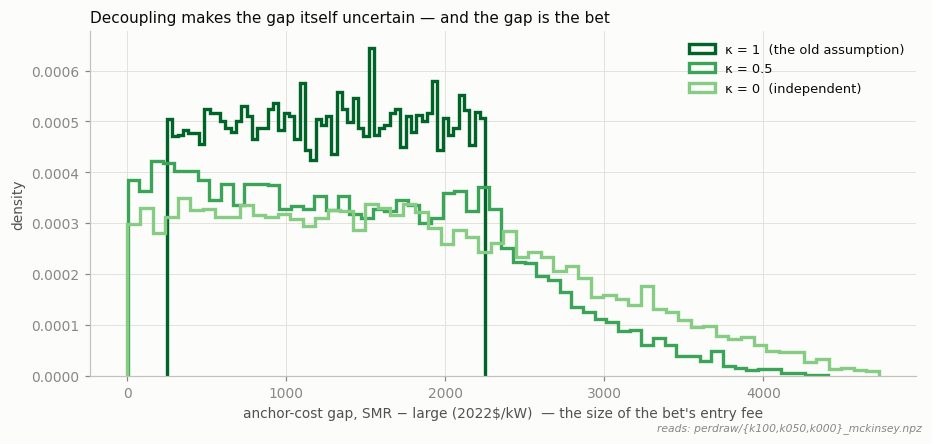

In [8]:
# §7 static companion - the price-tag gap distribution widens as the dial turns.
fig, ax = plt.subplots(figsize=(8.5, 4))
for cell, c in [("k100", plt.cm.Greens(0.9)), ("k050", plt.cm.Greens(0.65)),
                ("k000", plt.cm.Greens(0.45))]:
    w = load_perdraw(cell, REP_TOKEN)["world"]
    gap = w["boak_smr"] - w["boak_large"]
    ax.hist(gap, bins=60, histtype="step", lw=2.2, color=c, density=True,
            label=CELL_LABEL[cell])
ax.set_xlabel("anchor-cost gap, SMR − large (2022$/kW)  — the size of the bet's entry fee")
ax.set_ylabel("density")
ax.set_title("Decoupling makes the gap itself uncertain — and the gap is the bet",
             fontsize=10)
ax.legend(fontsize=8.5)
provenance(fig, f"perdraw/{{k100,k050,k000}}_{REP_TOKEN}.npz")
fig.tight_layout()
plt.show()

### §8 · The adversarial probes — letting the skeptic set the dial

Nobody knows the true κ. So the production run does not pick one: it sweeps the diagonal
(κ = 1, 0.75, 0.5, 0.25, 0) **and** adds two *probes* where the skeptic gets to set the
two halves of the dial separately — one κ for the price tags, another for the learning
rates:

- **Price tags coupled, learning independent** (κ_anchor=1, κ_learning=0): both
  technologies' sticker prices move together (they come from the same cost-study
  framework, so this is quite defensible), but how fast each *learns* is its own draw.
- **Learning coupled, price tags independent** (κ_learning=1, κ_anchor=0): the mirror —
  and, it turns out, **the setting most hostile to the SMR**: its learning advantage is
  locked to a fixed edge while its price-tag disadvantage roams free.

The rule of the game: *before believing a headline, hand a determined skeptic the
knobs.* Every "even at the probe" phrase in Part III refers to that second, adversarial
setting. Together: **7 dependence settings × 6 schedules = 42 cells**, each with 10,000
worlds — the master grid the results walk through.

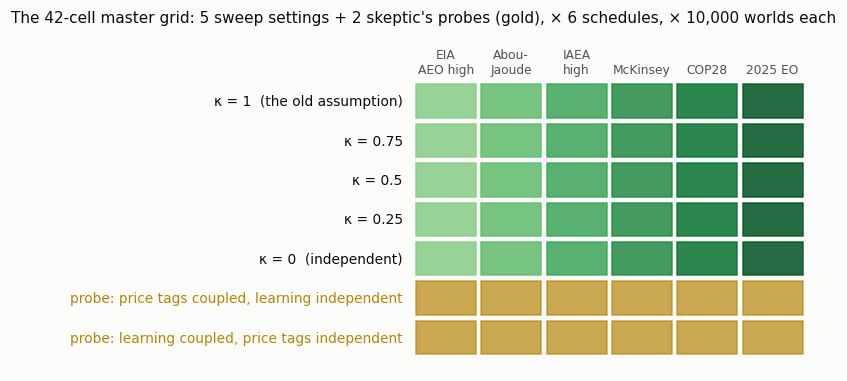

In [9]:
# §8 figure - the run grid at a glance.
fig, ax = plt.subplots(figsize=(9.5, 4))
ax.set_axis_off()
for i, cell in enumerate(CELL_ORDER):
    y = len(CELL_ORDER) - 1 - i
    kind = "probe" if cell.startswith("probe") else "sweep"
    for j, s in enumerate(SCHED_ORDER):
        ax.add_patch(plt.Rectangle((j, y), 0.92, 0.85,
                                   color=SCHED_COLORS[s] if kind == "sweep" else AMBER,
                                   alpha=0.85 if kind == "sweep" else 0.7))
    ax.text(-0.2, y + 0.42, CELL_LABEL[cell], ha="right", va="center", fontsize=9,
            color=INK if kind == "sweep" else AMBER)
for j, s in enumerate(SCHED_ORDER):
    ax.text(j + 0.46, len(CELL_ORDER) + 0.15, SCHED_SHORT[s], ha="center",
            fontsize=8, color=MUTED)
ax.set_xlim(-6.2, 6.2)
ax.set_ylim(-0.4, len(CELL_ORDER) + 1.2)
ax.set_title("The 42-cell master grid: 5 sweep settings + 2 skeptic's probes (gold), "
             "× 6 schedules, × 10,000 worlds each", fontsize=10)
plt.show()

### §9 · Calling the shot: the pre-registered claims ledger

Before the production run ever executed, seven claims **C1–C7** were written down with
exact falsification thresholds — the same discipline as registering a clinical trial
before enrolling patients. You announce what would count as evidence *before* you look,
so the goalposts cannot move afterward.

Here is the ledger with its final stamps — shown **before** any result, because the
score itself is the first result: **2 supported, 5 not supported.**

**The reframe that makes Part III readable:** a NOT SUPPORTED stamp does not mean the
analysis failed or the technology lost. It means *the pre-committed claim was too
strong*, and the way it failed — which cell, by how much, on whose assumptions — is
usually the most interesting finding in the study. Part III takes the claims in order,
one section each.

In [10]:
# §9 - the ledger, stamped (plain-English restatements alongside the registered text).
PLAIN = {
    "C1": "SMR is the cheaper program more often than not — in every cell, every schedule",
    "C2": "when large wins, it only ever wins by a hair (< 5% of program cost at P95)",
    "C3": "no committable strategy (mixes, delayed switches) beats all-SMR on expected cost",
    "C4": "every risk-averse planner would prefer the SMR program (stochastic dominance)",
    "C5": "the right to switch technologies in 2036 is worth < 1% — commitment is cheap",
    "C6": "the headline survives every single stress test (inflated SMR anchor, negative "
          "learning, cost floor, flexibility credit, CAPEX-only ranking, tax credit)",
    "C7": "all claims are explicitly scoped to the 'SMR bet' quadrant of assumptions",
}
led = LEDGER.copy()
led.insert(0, "plain-English claim", pd.Series(PLAIN))
led["verdict"] = np.where(led["supported"], "SUPPORTED", "NOT SUPPORTED")
show = led[["plain-English claim", "verdict", "numbers"]].rename(
    columns={"numbers": "the deciding numbers (from the run)"})

from matplotlib.colors import to_hex, to_rgb

def _pale(c, f=0.86):
    """Wash an accent toward white (fraction f): pale stamp backgrounds derived
    from the house GREEN/AMBER instead of free-standing hexes."""
    r, g, b = to_rgb(c)
    return to_hex((r + (1 - r) * f, g + (1 - g) * f, b + (1 - b) * f))

def _stamp_color(v):
    return (f"background-color: {_pale(GREEN)}; color: {GREEN}; font-weight: bold"
            if v == "SUPPORTED"
            else f"background-color: {_pale(AMBER)}; color: {AMBER}; font-weight: bold")

display(show.style.map(_stamp_color, subset=["verdict"])
            .set_properties(**{"text-align": "left", "font-size": "9.5pt"})
            .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))
print("reads: exports/tech_comparison/claims_ledger.csv (registered 2026-08-06, "
      "stamped by the production run)")

,plain-English claim,verdict,the deciding numbers (from the run)
claim,,,
C1,"SMR is the cheaper program more often than not — in every cell, every schedule",SUPPORTED,"min P(SMR) = 0.509 at (probe_lr1_boak0, EIA 2026 AEO high); CI lo 0.499"
C2,"when large wins, it only ever wins by a hair (< 5% of program cost at P95)",NOT SUPPORTED,"max P95 |m| | large wins = 30.83% at (probe_lr1_boak0, EIA 2026 AEO high) - tail reported, characterization dropped there"
C3,"no committable strategy (mixes, delayed switches) beats all-SMR on expected cost",NOT SUPPORTED,"beaten in 1 pairs, e.g. {('probe_lr1_boak0', 'EIA 2026 AEO high'): 'pure_large'}"
C4,every risk-averse planner would prefer the SMR program (stochastic dominance),NOT SUPPORTED,"SSD holds in 1/42 (cell, schedule) pairs; FSD in 0; CVaR95 comparison favors SMR in 29/42"
C5,the right to switch technologies in 2036 is worth < 1% — commitment is cheap,NOT SUPPORTED,"max PI option value = 5.882% of expected program cost at (probe_lr1_boak0, EIA 2026 AEO high) (threshold 1.0%) - noisy-signal tier now owed"
C6,"the headline survives every single stress test (inflated SMR anchor, negative learning, cost floor, flexibility credit, CAPEX-only ranking, tax credit)",NOT SUPPORTED,"breaking cells: OB x1.5@ob@k100 (minP=0.002, C3=False); OB x1.5@ob@k050 (minP=0.126, C3=False); OB x1.5@ob@k000 (minP=0.229, C3=False); NEGLR sym -15%@neglr_sym@k100 (minP=0.454, C3=False)"
C7,all claims are explicitly scoped to the 'SMR bet' quadrant of assumptions,SUPPORTED,outside the orthant P(SMR) spans 0.503..0.858; A2 off = modularity premise fails; stated in methods as bounding all claims


reads: exports/tech_comparison/claims_ledger.csv (registered 2026-08-06, stamped by the production run)


## Part III — The Results, claim by claim

### §10 · C1 — SUPPORTED — Reading the robustness map

**The claim:** SMR is the majority winner — cheaper in more than half the drawn worlds —
in *every* cell of the master grid, on *every* schedule.

**The verdict: SUPPORTED**, and the heatmap below is the paper's headline object. Read
it like a weather map. Rows are the dependence settings (skeptic's probes at the
bottom); columns are the schedules, least → most ambitious; each cell's number is the
share of its 10,000 worlds in which the SMR program is cheaper. **Hover any cell** for
the exact value, its statistical confidence interval, and the world count.

Two gradients carry the story:

- **Left to right (ambition):** more ambitious schedules build more units → more
  doublings → the SMR's learning advantage compounds → P(SMR) rises.
- **Top to bottom (decoupling):** as the shared luck dial is split apart, the cost gap
  gets riskier and large wins more of the draws — from ~0.87 typical at κ=1 down to
  ~0.63–0.81 at full independence.

**And the honesty callout, which belongs in the paper's own prose:** the worst cell —
the adversarial probe on the least ambitious schedule — comes in at **P(SMR) = 0.509,
with a confidence interval touching 0.499**. At the skeptic's own settings, on the
smallest program, this is *a coin flip, honestly labeled*. The claim survives on the
letter of its threshold, and we say so out loud rather than round it up.

In [11]:
# §10 PLOTLY 2 - the robustness map as an interactive heatmap.
_hm = ROB[ROB["cell"].isin(CELL_ORDER)].copy()
Zp = np.full((len(CELL_ORDER), len(SCHED_ORDER)), np.nan)
Cust = np.empty((len(CELL_ORDER), len(SCHED_ORDER), 3))
for i, cell in enumerate(CELL_ORDER):
    for j, s in enumerate(SCHED_ORDER):
        r = _hm[(_hm["cell"] == cell) & (_hm["schedule"] == s)].iloc[0]
        Zp[i, j] = r["P_smr"]
        Cust[i, j] = [r["ci_lo"], r["ci_hi"], r["n"]]
fig = go.Figure(go.Heatmap(
    z=Zp, x=SCHED_ORDER, y=[CELL_LABEL[c] for c in CELL_ORDER], customdata=Cust,
    zmid=0.5, zmin=0.45, zmax=1.0,
    colorscale=[[0.0, COL["large"]], [0.1, ps.NEUTRAL], [1.0, COL["smr"]]],
    text=np.round(Zp, 2), texttemplate="%{text:.2f}",
    colorbar=dict(title="P(SMR wins)"),
    hovertemplate=("%{y}<br>%{x}<br>P(SMR wins) = %{z:.3f} "
                   "(95% CI %{customdata[0]:.3f}–%{customdata[1]:.3f}, "
                   "n = %{customdata[2]:,.0f} worlds)<extra></extra>")))
fig.add_annotation(x=SCHED_ORDER[0], y=CELL_LABEL["probe_lr1_boak0"],
                   text="the coin-flip corner:<br>0.509 (CI touches 0.499)",
                   showarrow=True, arrowhead=2, ax=110, ay=45,
                   font=dict(color=INK, size=11), arrowcolor=INK)
ps.plotly_layout(fig, height=460, width=1000,
                 title="C1, the robustness map: share of drawn worlds where the SMR program "
                       "is cheaper (orange = SMR territory)")
fig.update_yaxes(autorange="reversed")
fig.show()
print("reads: exports/tech_comparison/robustness_map.csv")

reads: exports/tech_comparison/robustness_map.csv


### §11 · C2 — NOT SUPPORTED — When large wins, how badly does SMR lose?

**The claim:** whenever large turns out to be the cheaper program, it is only ever by a
hair — less than 5% of program cost even at the 95th percentile of those cases.

**The verdict: NOT SUPPORTED — and this failure was half-expected when the claim was
registered.** C1 asked *how often* the SMR bet loses; C2 asks *how badly when it does* —
the difference between "how often do I crash?" and "how big is the crash?". A good
insurance analyst never conflates them, and neither should the paper.

At κ=1 (shared luck), losses are indeed small: when large wins, the gap is a few percent.
But as the dial decouples, the losing tail stretches: at the adversarial probe, the 95th
percentile of losses (among large-win worlds) reaches **≈ 31% of program cost** — for
programs measured in hundreds of billions, real money.

One guardrail against over-reading: these are the loss sizes *within the minority of
worlds where large wins* (13–49% of worlds, depending on the cell). A 31% loss that
occurs in part of a minority of scenarios is a *tail risk*, not an expected outcome —
but the pre-registered claim said the tail was negligible, and it is not. The
characterization "when large wins, it wins narrowly" is therefore **dropped** for the
decoupled cells and survives only near κ=1.

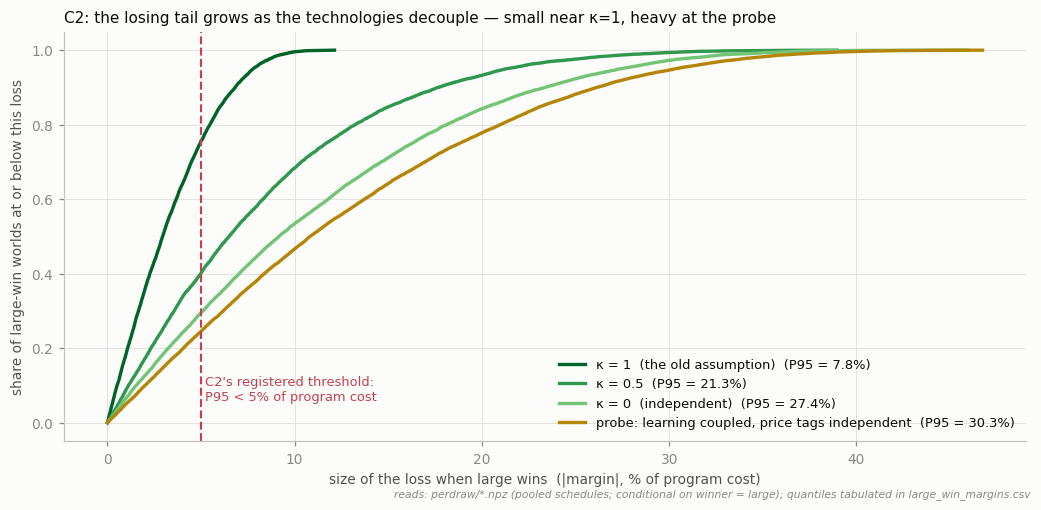

In [12]:
# §11 figure - the losing tail, cell by cell.
fig, ax = plt.subplots(figsize=(9.5, 4.6))
_cells11 = ["k100", "k050", "k000", "probe_lr1_boak0"]
_greens11 = [plt.cm.Greens(0.9), plt.cm.Greens(0.7), plt.cm.Greens(0.5), AMBER]
for cell, c in zip(_cells11, _greens11):
    absm = np.concatenate([np.abs(load_perdraw(cell, t)["m_pct"]
                                  [load_perdraw(cell, t)["winner"] == "large"])
                           for t in TOKEN_NAME])
    xs = np.sort(absm)
    ax.plot(xs, np.linspace(0, 1, len(xs)), lw=2.2, color=c,
            label=f"{CELL_LABEL[cell]}  (P95 = {np.percentile(absm, 95):.1f}%)")
ax.axvline(5.0, color=RED, lw=1.4, ls="--")
ax.text(5.2, 0.06, "C2's registered threshold:\nP95 < 5% of program cost",
        fontsize=8.5, color=RED)
ax.set_xlabel("size of the loss when large wins  (|margin|, % of program cost)")
ax.set_ylabel("share of large-win worlds at or below this loss")
ax.set_title("C2: the losing tail grows as the technologies decouple — small near κ=1, "
             "heavy at the probe", fontsize=10)
ax.legend(fontsize=8.5, loc="lower right")
provenance(fig, "perdraw/*.npz (pooled schedules; conditional on winner = large); "
                "quantiles tabulated in large_win_margins.csv")
fig.tight_layout()
plt.show()

### §12 · C3 — NOT SUPPORTED (barely) — The commitment tournament

**The claim:** among every plan a policymaker could *commit to in ink today* — all-large,
all-SMR, any constant mix (70/30, 50/50, …), or any "one technology until year τ, then
the other" switch — the all-SMR program has the lowest expected cost in every cell and
schedule.

Why restrict to fixed, committable plans? Because none of them get to peek at how costs
actually unfold — which isolates the pure *commitment* question. (What peeking would be
worth is priced separately: §14 and §15.)

**The verdict: NOT SUPPORTED — by exactly one cell out of 42.** All-SMR is the
expected-cost winner in 41 of 42 (cell × schedule) contests among the 49 registered
strategies. The single exception is, once again, the adversarial probe on the least
ambitious schedule, where all-large edges it. No *mixed* strategy — no hedge, no
constant split, no delayed switch — takes first place anywhere: learning rewards
concentration, so the tournament is always corner-vs-corner.

**Hover the strip below** to identify individual strategies (49 labels cannot fit on a
static axis): the corners at the extremes, the constant mixes strung between them, and
the switch families in between.

In [13]:
# §12 PLOTLY 3 - the 49-strategy tournament in one representative cell.
_ex_cell = "k050"
_ex = EXANTE[(EXANTE["cell"] == _ex_cell) & (EXANTE["schedule"] == REP_SCHED)].copy()
def _family(nm):
    if nm.startswith("pure"):
        return "pure corner"
    if nm.startswith("const"):
        return "constant mix"
    return "switch plan"
_ex["family"] = _ex["strategy"].map(_family)
_fam_color = {"pure corner": INK, "constant mix": ps.C_FULL, "switch plan": ps.C_TINY}
_fam_y = {"pure corner": 2, "constant mix": 1, "switch plan": 0}
rng_j = np.random.default_rng(7)
fig = go.Figure()
for fam, sub in _ex.groupby("family"):
    fig.add_trace(go.Scatter(
        x=as_bn(sub["E_cost"]), y=_fam_y[fam] + rng_j.uniform(-0.22, 0.22, len(sub)),
        mode="markers",
        marker=dict(size=9, color=_fam_color[fam], symbol="circle", opacity=0.8),
        name=fam, customdata=np.column_stack([sub["strategy"], as_bn(sub["P95"]),
                                              as_bn(sub["CVaR95"]), sub["rank_E"]]),
        hovertemplate=("<b>%{customdata[0]}</b><br>expected cost $%{x:,.0f} bn<br>"
                       "P95 $%{customdata[1]:,.0f} bn · bad-day average (CVaR95) "
                       "$%{customdata[2]:,.0f} bn<br>rank by expected cost: "
                       "%{customdata[3]:.0f} of 49<extra></extra>")))
_best = _ex[_ex["rank_E"] == 1].iloc[0]
fig.add_trace(go.Scatter(x=[as_bn(_best["E_cost"])], y=[_fam_y[_family(_best["strategy"])]],
                         mode="markers+text", text=[f"#1: {_best['strategy']}"],
                         textposition="top center", textfont=dict(color=COL["smr"], size=12),
                         marker=dict(size=16, symbol="diamond", color=COL["smr"],
                                     line=dict(color=INK, width=1.5)),
                         name="the winner", hoverinfo="skip"))
ps.plotly_layout(fig, height=420, width=980,
                 title=f"C3, the commitment tournament — 49 committable plans, "
                       f"{CELL_LABEL[_ex_cell]}, {REP_SCHED} (hover to identify)",
                 xaxis_title="expected program cost (2022$B, npv)")
# yaxis= would collide with plotly_layout's own yaxis kwarg; merge the tick relabel after.
fig.update_layout(yaxis=dict(tickvals=[0, 1, 2],
                             ticktext=["switch plans", "constant mixes", "pure corners"]))
fig.show()
print("reads: exports/tech_comparison/exante_ranking.csv")

reads: exports/tech_comparison/exante_ranking.csv


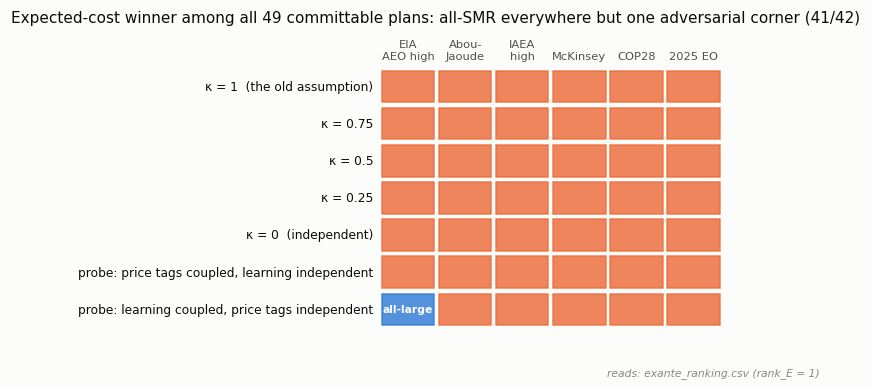

In [14]:
# §12 static companion - where does all-SMR rank #1? (the 42-cell mini-map)
PRIMARY_CELLS = CELL_ORDER
win1 = EXANTE[(EXANTE["rank_E"] == 1) & (EXANTE["cell"].isin(PRIMARY_CELLS))]
fig, ax = plt.subplots(figsize=(8.5, 3.6))
for i, cell in enumerate(PRIMARY_CELLS):
    for j, s in enumerate(SCHED_ORDER):
        w = win1[(win1["cell"] == cell) & (win1["schedule"] == s)]["strategy"].iloc[0]
        ok = w == "pure_smr"
        ax.add_patch(plt.Rectangle((j, len(PRIMARY_CELLS)-1-i), 0.92, 0.85,
                                   color=COL["smr"] if ok else COL["large"], alpha=0.8))
        if not ok:
            ax.text(j+0.46, len(PRIMARY_CELLS)-1-i+0.42, w.replace("pure_", "all-"),
                    ha="center", va="center", fontsize=7, color="white", weight="bold")
    ax.text(-0.15, len(PRIMARY_CELLS)-1-i+0.42, CELL_LABEL[cell], ha="right",
            va="center", fontsize=8, color=INK)
for j, s in enumerate(SCHED_ORDER):
    ax.text(j+0.46, len(PRIMARY_CELLS)+0.15, SCHED_SHORT[s], ha="center", fontsize=7.5,
            color=MUTED)
ax.set_xlim(-6.5, 6.2)
ax.set_ylim(-0.3, len(PRIMARY_CELLS)+0.9)
ax.set_axis_off()
ax.set_title("Expected-cost winner among all 49 committable plans: all-SMR everywhere "
             "but one adversarial corner (41/42)", fontsize=10)
provenance(fig, "exante_ranking.csv (rank_E = 1)")
plt.show()

### §13 · C4 — NOT SUPPORTED — Is SMR better in *every* sense? Dominance and the bad-day average

**The claim** used a strong economist's tool. A gamble A **second-order stochastically
dominates** gamble B when *every* risk-averse decision-maker — mildly cautious or
paranoid, without exception — prefers A. It is a **unanimity test**. The claim was that
the SMR program dominates the large program in every cell: not just cheaper on average,
but better for everyone who dislikes risk, full stop.

**The verdict: NOT SUPPORTED, decisively — unanimity holds in only 1 of 42 contests.**
The reason is visible in the cost curves below: the two distributions **cross in the
expensive tail**. The SMR program is cheaper through most of the distribution, but its
*worst* worlds (pricey anchor + disappointing learning, at scale) are worse than the
large program's worst worlds. A sufficiently loss-focused planner can therefore
rationally prefer large — which is precisely why the paper reports more than a win
probability.

The registered fallback was a weaker, concrete risk measure: **CVaR₉₅ — "the bad-day
average"**, the mean cost across the worst 1-in-20 worlds. On that measure the SMR
program is still preferred in **29 of 42** contests — most, not all.

**This does not contradict C1.** "Usually cheaper" (C1), "sometimes loses big" (C2), and
"not unanimously preferred" (C4) are three different questions about the same
distributions; the analysis's contribution is refusing to collapse them into one number.

C:\Users\ethan\AppData\Local\Temp\ipykernel_25868\3409807996.py:52: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



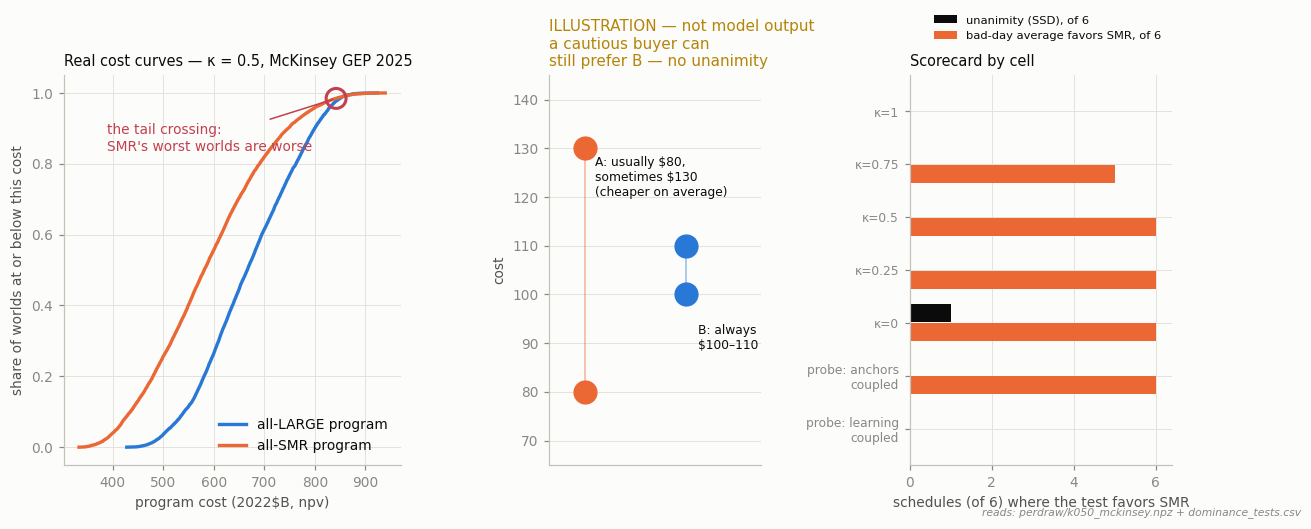

In [15]:
# §13 figure - the crossing that kills unanimity, plus the toy that defines it.
fig = plt.figure(figsize=(13, 4.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.35, 0.85, 1.05], wspace=0.55)
ax = fig.add_subplot(gs[0])
pdc = load_perdraw("k050", REP_TOKEN)
for tech, arr in [("large", pdc["R_large"]), ("smr", pdc["R_smr"])]:
    xs = np.sort(as_bn(arr))
    ax.plot(xs, np.linspace(0, 1, len(xs)), color=COL[tech], lw=2.2,
            label=f"all-{tech.upper()} program")
_dm = DOM[(DOM["cell"] == "k050") & (DOM["schedule"] == REP_SCHED)].iloc[0]
_xc = (as_bn(_dm["crossing_cost"]) if np.isfinite(_dm["crossing_cost"])
       else np.quantile(as_bn(pdc["R_smr"]), 0.995))
_q = float((as_bn(pdc["R_smr"]) <= _xc).mean())
ax.scatter([_xc], [_q], s=170, facecolor="none", edgecolor=RED, lw=2, zorder=5)
ax.annotate("the tail crossing:\nSMR's worst worlds are worse",
            (_xc, _q), textcoords="offset points", xytext=(-150, -34), fontsize=9,
            color=RED, arrowprops=dict(arrowstyle="-", color=RED, lw=1))
ax.set_xlabel("program cost (2022$B, npv)")
ax.set_ylabel("share of worlds at or below this cost")
ax.set_title(f"Real cost curves — {CELL_LABEL['k050']}, {REP_SCHED}", fontsize=9.5)
ax.legend(fontsize=9, loc="lower right")

ax = fig.add_subplot(gs[1])
ax.scatter([0, 0], [80, 130], s=220, color=COL["smr"], zorder=3)
ax.scatter([1, 1], [100, 110], s=220, color=COL["large"], zorder=3)
ax.plot([0, 0], [80, 130], color=COL["smr"], lw=1, alpha=0.5)
ax.plot([1, 1], [100, 110], color=COL["large"], lw=1, alpha=0.5)
ax.text(0.1, 124, "A: usually $80,\nsometimes $130\n(cheaper on average)",
        fontsize=8, color=INK, va="center")
ax.text(1.12, 91, "B: always\n$100–110", fontsize=8, color=INK, va="center")
ax.set_xlim(-0.35, 1.75)
ax.set_ylim(65, 145)
ax.set_xticks([])
ax.set_ylabel("cost")
illustration(ax, "a cautious buyer can\nstill prefer B — no unanimity")

ax = fig.add_subplot(gs[2])
_dcnt = DOM.groupby("cell")[["SSD_smr", "CVaR95_smr_le_large"]].sum().reindex(CELL_ORDER)
_short_cell = {"k100": "κ=1", "k075": "κ=0.75", "k050": "κ=0.5", "k025": "κ=0.25",
               "k000": "κ=0", "probe_lr0_boak1": "probe: anchors\ncoupled",
               "probe_lr1_boak0": "probe: learning\ncoupled"}
y = np.arange(len(CELL_ORDER))[::-1]
ax.barh(y + 0.18, _dcnt["SSD_smr"], height=0.34, color=INK, label="unanimity (SSD), of 6")
ax.barh(y - 0.18, _dcnt["CVaR95_smr_le_large"], height=0.34, color=COL["smr"],
        label="bad-day average favors SMR, of 6")
ax.set_yticks(y)
ax.set_yticklabels([_short_cell[c] for c in CELL_ORDER], fontsize=8)
ax.set_xlabel("schedules (of 6) where the test favors SMR")
ax.set_xlim(0, 6.4)
ax.set_title("Scorecard by cell", fontsize=9.5)
ax.legend(fontsize=7.5, loc="upper right", bbox_to_anchor=(1.0, 1.18))
fig.tight_layout(rect=[0, 0.04, 1, 1])
provenance(fig, f"perdraw/k050_{REP_TOKEN}.npz + dominance_tests.csv")
plt.show()

### §14 · C5 — NOT SUPPORTED — What is the right to change your mind worth?

**The claim:** commitment is nearly free — if you could observe how costs unfold and
switch technologies in 2036 *with perfect hindsight*, that flexibility would be worth
less than 1% of program cost. (Think of it as a **return policy**: how much extra would
you rationally pay for a no-questions-asked exchange window in 2036?)

**The verdict: NOT SUPPORTED.** Near κ=1 the claim holds comfortably — knowing more
barely changes the decision, so the exchange window is worth little. But in the
decoupled and probe cells the option value climbs to **≈ 5.9% of program cost** — far
over the registered 1% line. Where the bet is shakiest is exactly where the right to
revisit it is valuable.

Two consequences, both now owed by the pre-registration: **(1)** adaptive, staged
strategies are promoted from a footnote to future work with paper space ("sequencing
gets paper space"); **(2)** the number here is an *upper bound* — it assumes the 2036
decision-maker sees the truth, while a real one would see noisy first-of-a-kind data —
so the promised follow-up is a noisy-information tier, not a bigger claim.

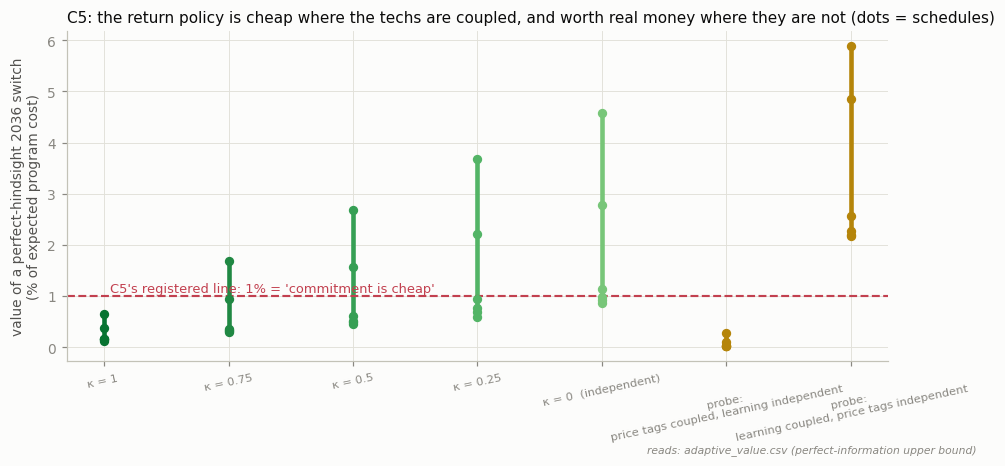

In [16]:
# §14 figure - the exchange-window's value, cell by cell.
fig, ax = plt.subplots(figsize=(9, 4.2))
for j, cell in enumerate(CELL_ORDER):
    d = ADAPT[ADAPT["cell"] == cell]["bound_pct"]
    color = AMBER if cell.startswith("probe") else plt.cm.Greens(0.85 - 0.09*j)
    ax.plot([j, j], [d.min(), d.max()], color=color, lw=3, solid_capstyle="round")
    ax.scatter(np.full(len(d), j), d, s=26, color=color, zorder=4)
ax.axhline(1.0, color=RED, lw=1.4, ls="--")
ax.text(0.05, 1.08, "C5's registered line: 1% = 'commitment is cheap'", fontsize=8.5,
        color=RED)
ax.set_xticks(range(len(CELL_ORDER)))
ax.set_xticklabels([CELL_LABEL[c].replace(" (the old assumption)", "")
                    .replace("probe: ", "probe:\n") for c in CELL_ORDER],
                   fontsize=7.5, rotation=12)
ax.set_ylabel("value of a perfect-hindsight 2036 switch\n(% of expected program cost)")
ax.set_title("C5: the return policy is cheap where the techs are coupled, and worth "
             "real money where they are not (dots = schedules)", fontsize=10)
provenance(fig, "adaptive_value.csv (perfect-information upper bound)")
fig.tight_layout()
plt.show()

### §15 · The crystal-ball audit: what would resolving the uncertainty be worth?

Before the stress tests, a budgeting question: **if a study, a demonstration program, or
a first-of-a-kind data release could resolve part of this uncertainty, what is the most
that information could be worth to the decision?** Economists call the ceiling the
**EVPI — expected value of perfect information**: the gap between committing to the best
plan now and being able to pick the best plan *after* seeing the truth. If a proposed
research program costs more than the EVPI, it cannot pay for itself through this
decision, no matter how good the science.

Two layers below:

- **Total EVPI** (left): resolving *everything* is worth between ~0.1% (coupled cells —
  the decision barely depends on the unknowns there) and **~6% of program cost**
  (decoupled and probe cells). Same shape as §14, and for the same reason: information
  is valuable exactly where the bet is shakiest.
- **By parameter** (right): *which* unknown moves the decision? The **anchor-cost gap
  dominates**, with the learning-rate gap second, the experience-base convention third,
  and κ itself contributing through the cell pooling. The policy translation writes
  itself: the decision-relevant unknown is the SMR price tag — and the only instrument
  that truly resolves a price tag is **building the first units**. Which loops straight
  back to §14: early SMR units are not just capacity, they are the information purchase.

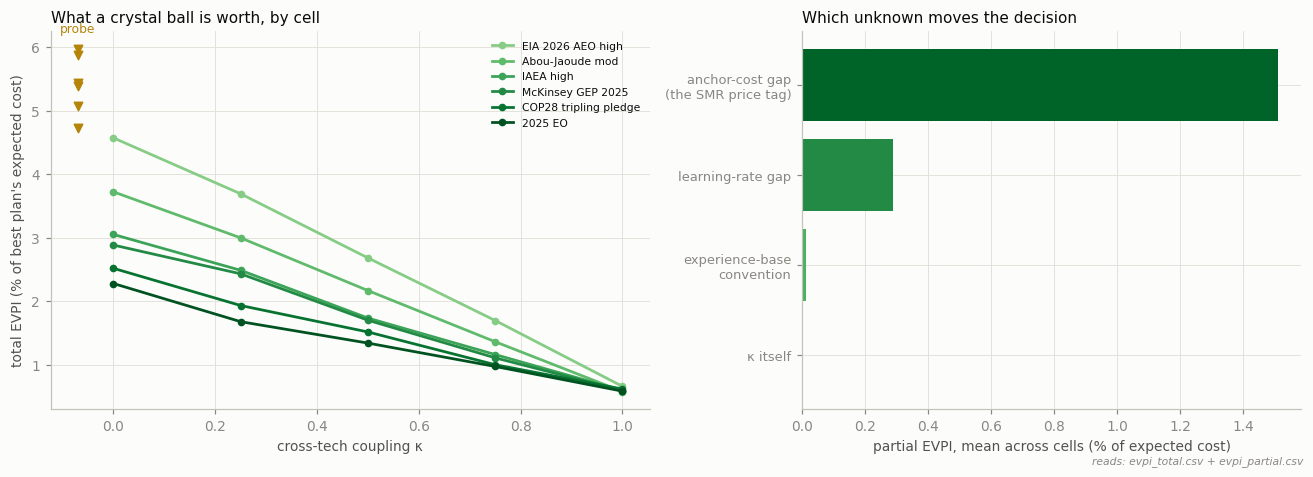

In [17]:
# §15 figure - EVPI, total and by parameter.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), gridspec_kw={"width_ratios": [1.2, 1]})
ax = axes[0]
for sched in SCHED_ORDER:
    d = EVPI_TOT[(EVPI_TOT["schedule"] == sched)
                 & (EVPI_TOT["cell"].isin(KAPPA_CELLS))].copy()
    d["kappa"] = d["cell"].map(KAPPA_CELLS)
    d = d.sort_values("kappa")
    ax.plot(d["kappa"], d["EVPI_pct"], color=SCHED_COLORS[sched], lw=1.8, marker="o",
            ms=4, label=sched)
_pr = EVPI_TOT[EVPI_TOT["cell"] == "probe_lr1_boak0"]["EVPI_pct"]
ax.scatter(np.full(len(_pr), -0.07), _pr, marker="v", s=30, color=AMBER, zorder=4)
ax.text(-0.07, float(_pr.max()) + 0.25, "probe", ha="center", fontsize=8, color=AMBER)
ax.set_xlabel("cross-tech coupling κ")
ax.set_ylabel("total EVPI (% of best plan's expected cost)")
ax.set_title("What a crystal ball is worth, by cell", fontsize=10)
ax.legend(fontsize=7)
ax = axes[1]
_pp = (EVPI_PART[EVPI_PART["parameter"] != "kappa"]
       .groupby("parameter")["partial_EVPI_pct"].mean())
_pp.loc["kappa (cell pooling)"] = EVPI_PART[EVPI_PART["parameter"] == "kappa"
                                            ]["partial_EVPI_pct"].mean()
_lbl = {"boak_gap": "anchor-cost gap\n(the SMR price tag)", "lr_gap": "learning-rate gap",
        "conv_full": "experience-base\nconvention",
        "kappa (cell pooling)": "κ itself"}
_pp = _pp.sort_values()
ax.barh(range(len(_pp)), _pp.values, color=plt.cm.Greens(np.linspace(0.45, 0.9, len(_pp))))
ax.set_yticks(range(len(_pp)))
ax.set_yticklabels([_lbl.get(i, i) for i in _pp.index], fontsize=8.5)
ax.set_xlabel("partial EVPI, mean across cells (% of expected cost)")
ax.set_title("Which unknown moves the decision", fontsize=10)
provenance(fig, "evpi_total.csv + evpi_partial.csv")
fig.tight_layout()
plt.show()

### §16 · C6 — NOT SUPPORTED — The stress that flips the answer

**The claim:** the headline (C1 and C3) survives every one of seven single stress tests,
applied one at a time at the anchor cells: an inflated SMR anchor, negative learning
(both flavors), a cost floor, a flexibility credit for SMR, ranking on construction cost
alone, and a 30% investment tax credit for both.

**The verdict: NOT SUPPORTED — one stress breaks everything, and it is the one the
paper must talk about.** The ladder below shows each stress's range of P(SMR) across the
anchor cells and schedules:

- **Five stresses are shrugged off** (cost floor φ=0.5, flexibility credits, CAPEX-only
  ranking, ITC): P(SMR) stays comfortably above 0.5 everywhere. The winner is not an
  artifact of the cost object or of ignoring flexibility.
- **Negative learning (both techs, −15% floor — the French experience)** is a graze:
  P(SMR) dips to 0.454 at κ=1 in the worst schedule, survives elsewhere.
- **The optimism-bias stress — SMR anchor × 1.5 — flips the answer outright:** P(SMR)
  collapses to 0.002–0.23. Not a dent; a reversal.

**Why that stress exists, told straight (the receipts-vs-estimates story).** The two
anchor ranges come from the same cost study, processed the same way — but from
different *kinds* of evidence. The large-reactor range is anchored partly on **realized
builds** — actual invoices from actual projects (Vogtle and its ancestors). The SMR
range rests on **vendor engineering estimates for machines with zero completed units**.
The cost-overrun literature (RAND's pioneer-plants work; NuScale's own published
estimate revisions; MIT's cost-escalation post-mortems) finds that estimates at that
maturity stage have historically come in low by ~50% or more, on average — which is
exactly what ×1.5 encodes. It is not a paranoid case; it is the documented base rate.

**The honest sentence the pre-registration forces into the paper:** *the SMR
conclusion is conditional on SMR vendor estimates being off by less than ~50% — the
historical base rate for estimates at this maturity.* We committed to this stress
before seeing the result, so it gets printed with its numbers rather than negotiated
away. And per §15, the datum that would settle it — a realized first-of-a-kind cost —
is precisely what early units buy.

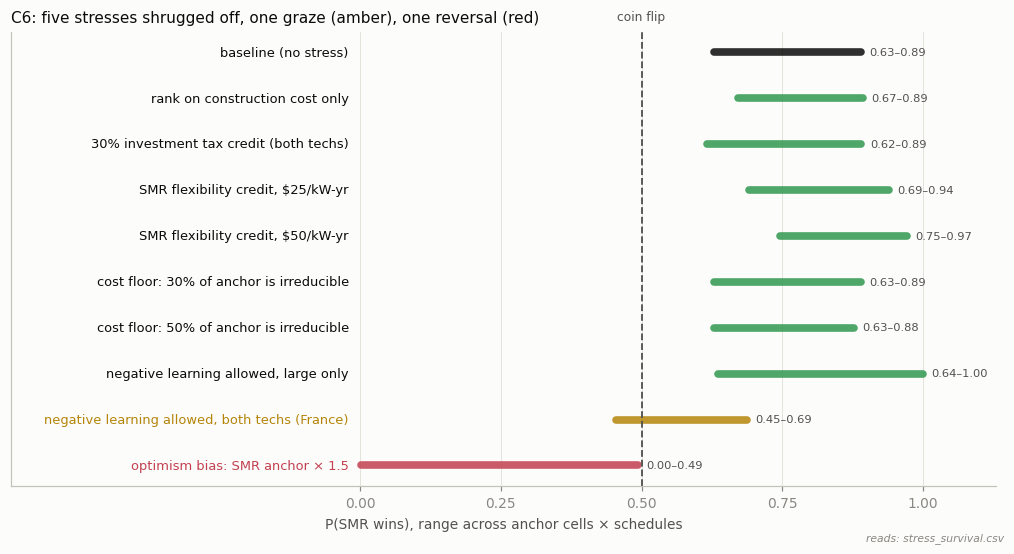

In [18]:
# §16 figure - the stress ladder.
_order16 = ["baseline (default)", "capex object", "ITC 30%", "FLEX 25", "FLEX 50",
            "floor phi=0.3", "floor phi=0.5", "NEGLR large_only -15%", "NEGLR sym -15%",
            "OB x1.5"]
_label16 = {"baseline (default)": "baseline (no stress)",
            "capex object": "rank on construction cost only",
            "ITC 30%": "30% investment tax credit (both techs)",
            "FLEX 25": "SMR flexibility credit, $25/kW-yr",
            "FLEX 50": "SMR flexibility credit, $50/kW-yr",
            "floor phi=0.3": "cost floor: 30% of anchor is irreducible",
            "floor phi=0.5": "cost floor: 50% of anchor is irreducible",
            "NEGLR large_only -15%": "negative learning allowed, large only",
            "NEGLR sym -15%": "negative learning allowed, both techs (France)",
            "OB x1.5": "optimism bias: SMR anchor × 1.5"}
agg = STRESS.groupby("stress").agg(lo=("min_P_smr", "min"), hi=("max_P_smr", "max"))
fig, ax = plt.subplots(figsize=(9.5, 5))
for k, st in enumerate(_order16):
    y = len(_order16) - 1 - k
    lo, hi = agg.loc[st, "lo"], agg.loc[st, "hi"]
    c = (RED if st == "OB x1.5" else AMBER if st == "NEGLR sym -15%"
         else INK if st.startswith("baseline") else plt.cm.Greens(0.7))
    ax.plot([lo, hi], [y, y], color=c, lw=5, solid_capstyle="round", alpha=0.85)
    ax.text(min(lo, 0.0) - 0.02, y, _label16[st], ha="right", va="center", fontsize=8.5,
            color=c if c in (RED, AMBER) else INK)
    ax.text(hi + 0.015, y, f"{lo:.2f}–{hi:.2f}", va="center", fontsize=7.5, color=MUTED)
ax.axvline(0.5, color=MUTED, lw=1.2, ls="--")
ax.text(0.5, len(_order16) - 0.3, "coin flip", ha="center", fontsize=8, color=MUTED)
ax.set_xlim(-0.62, 1.13)
ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])   # the negative region is label space, not P
ax.set_yticks([])
ax.set_xlabel("P(SMR wins), range across anchor cells × schedules")
ax.set_title("C6: five stresses shrugged off, one graze (amber), one reversal (red)",
             fontsize=10)
provenance(fig, "stress_survival.csv")
fig.tight_layout()
plt.show()

### §17 · C7 — SUPPORTED — The fine print, printed large

**The claim (a discipline, not a result):** every conclusion is explicitly scoped to the
**"SMR bet" quadrant of assumptions** — worlds where the SMR both *starts more
expensive* (A1) and *learns faster* (A2). Outside that quadrant there is no bet to
analyze: if SMRs are actually cheaper up front, the choice is trivial; if they do not
learn faster, the modularity premise has failed and large wins by default. The
production run prices the other quadrants once (as scope documentation) and claims
nothing there. **Verdict: SUPPORTED** — the scoping is stated and maintained.

> **Before you quote this notebook — the misreadings checklist**
>
> - *"P(SMR wins) = the probability SMRs get built."* No — share of drawn cost-worlds,
>   conditional on a mandated schedule; silent on politics, licensing, siting, demand.
> - *"0.63–0.89 means we are 63–89% sure."* These probabilities live inside the stated
>   evidence ranges and coupling assumptions; §16 shows how they move when an
>   assumption moves.
> - *"C1 supported but C2/C4 failed — contradiction."* Frequency, severity, and
>   unanimity are three different questions; the paper refuses to collapse them.
> - *"5 of 7 NOT SUPPORTED = the study failed."* The stamps grade our pre-registered
>   claims, not the technology or the study; each failure carries its own finding.
> - *"The optimism-bias flip means the baseline is wrong."* It means the result is
>   conditional on estimate quality — and names the datum (realized FOAK cost) that
>   would settle it.
> - *"EVPI is money someone receives."* It is a ceiling on what information could be
>   worth, used to screen research proposals.
> - *"This tells ReEDS what to build."* No system-value feedbacks here; it prices a
>   mandated program, full stop (§6 sidebar).

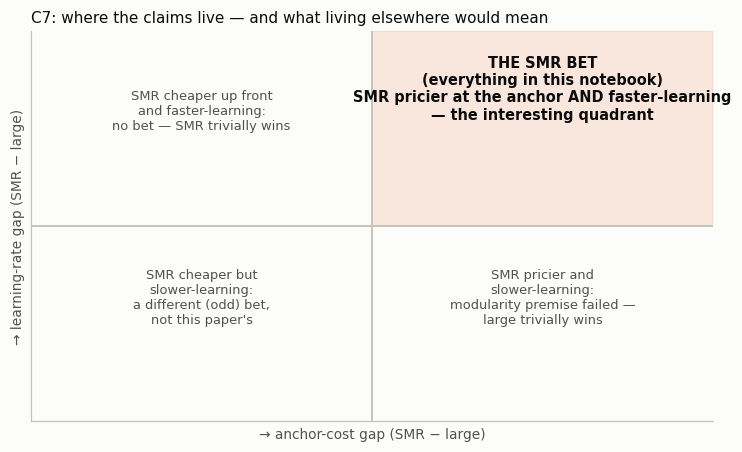

In [19]:
# §17 figure - the quadrant of assumptions.
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.axhline(0, color=EDGE_C, lw=1.2)
ax.axvline(0, color=EDGE_C, lw=1.2)
ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=COL["smr"], alpha=0.14))
ax.text(0.5, 0.55, "THE SMR BET\n(everything in this notebook)\nSMR pricier at the "
        "anchor AND faster-learning\n— the interesting quadrant", ha="center",
        fontsize=9.5, color=INK, weight="bold")
ax.text(-0.5, 0.5, "SMR cheaper up front\nand faster-learning:\nno bet — SMR trivially "
        "wins", ha="center", fontsize=8.5, color=MUTED)
ax.text(0.5, -0.5, "SMR pricier and\nslower-learning:\nmodularity premise failed —\n"
        "large trivially wins", ha="center", fontsize=8.5, color=MUTED)
ax.text(-0.5, -0.5, "SMR cheaper but\nslower-learning:\na different (odd) bet,\nnot "
        "this paper's", ha="center", fontsize=8.5, color=MUTED)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("→ anchor-cost gap (SMR − large)")
ax.set_ylabel("→ learning-rate gap (SMR − large)")
ax.set_title("C7: where the claims live — and what living elsewhere would mean",
             fontsize=10)
plt.show()

## Part IV — Wrap

### §18 · What should you actually take away?

The ledger scored 2-of-7 — so is the SMR bet good or not? A three-sentence synthesis
(**draft language for our discussion, not settled paper text**):

> *The SMR program wins the expected-cost race in nearly every world we can defend
> drawing — but not by unanimity (the cost distributions cross in the expensive tail),
> not with sequencing settled (the right to revisit the choice in 2036 is worth real
> money exactly where the bet is shakiest), and only if vendor estimates survive contact
> with reality (the one stress that flips everything). The honest headline is not "SMRs
> win"; it is "commit to nuclear, lean SMR, stage the irreversibility, and buy
> information early." The pre-registration is why that ordering of caveats can be
> trusted: it could not have been rearranged after seeing the results.*

In [20]:
# §18 - the one-table summary.
TAKEAWAY = pd.DataFrame([
    ("C1", "SUPPORTED", "SMR is the majority winner in every cell — but one adversarial "
     "corner is an honest coin flip (0.509)."),
    ("C2", "NOT SUPPORTED", "When large wins in decoupled worlds, losses can be large "
     "(P95 ≈ 31% at the probe) — the 'narrow loss' line is dropped there."),
    ("C3", "NOT SUPPORTED", "All-SMR is the best committable plan in 41/42 contests; no "
     "hedge or mix ever wins — concentration beats splitting."),
    ("C4", "NOT SUPPORTED", "No unanimity: SMR's worst tail is worse, so a very "
     "risk-averse planner can prefer large; the bad-day average still favors SMR in "
     "29/42."),
    ("C5", "NOT SUPPORTED", "Flexibility to switch in 2036 is worth up to ~6% of program "
     "cost — sequencing earns paper space and a noisy-information follow-up."),
    ("C6", "NOT SUPPORTED", "One stress reverses the headline: SMR anchor ×1.5 (the "
     "documented optimism base rate for pre-build estimates). Everything else survives."),
    ("C7", "SUPPORTED", "All claims are scoped to the SMR-bet quadrant and say so."),
], columns=["claim", "verdict", "so-what for the paper"]).set_index("claim")
display(TAKEAWAY.style.map(_stamp_color, subset=["verdict"])
        .set_properties(**{"text-align": "left", "font-size": "9.5pt"}))
print("reads: claims_ledger.csv (verdicts) - the so-what column is this notebook's "
      "editorial gloss, for discussion")

,verdict,so-what for the paper
claim,,
C1,SUPPORTED,SMR is the majority winner in every cell — but one adversarial corner is an honest coin flip (0.509).
C2,NOT SUPPORTED,"When large wins in decoupled worlds, losses can be large (P95 ≈ 31% at the probe) — the 'narrow loss' line is dropped there."
C3,NOT SUPPORTED,All-SMR is the best committable plan in 41/42 contests; no hedge or mix ever wins — concentration beats splitting.
C4,NOT SUPPORTED,"No unanimity: SMR's worst tail is worse, so a very risk-averse planner can prefer large; the bad-day average still favors SMR in 29/42."
C5,NOT SUPPORTED,Flexibility to switch in 2036 is worth up to ~6% of program cost — sequencing earns paper space and a noisy-information follow-up.
C6,NOT SUPPORTED,One stress reverses the headline: SMR anchor ×1.5 (the documented optimism base rate for pre-build estimates). Everything else survives.
C7,SUPPORTED,All claims are scoped to the SMR-bet quadrant and say so.


reads: claims_ledger.csv (verdicts) - the so-what column is this notebook's editorial gloss, for discussion


### §19 · Glossary and reader's guide

| Term | Plain meaning | Introduced | Analogy used |
|---|---|---|---|
| anchor cost | price per kW of the first (2030) units — the sticker price | §1 | — |
| learning rate | % cost drop per *doubling* of cumulative units | §1, §5 | downhill slope in doublings |
| drawn world | one internally consistent set of all uncertain inputs | §4 | parallel universe, one trading card |
| "rides the same percentile" | within one tech, all cost dials share one luck knob | §4 | one luck dial per tech |
| program NPV | all construction + 30 yr of operating costs, discounted to 2030 | §6 | the time-machine price tag |
| κ (kappa) | 0–1 dial coupling the two techs' draws | §7 | two students, same exam |
| adversarial probe | the coupling setting chosen to be most hostile to SMR | §8 | the worst-case referee |
| pre-registration | claims + thresholds fixed before the run | §9 | clinical-trial registration |
| margin | cost gap between the two programs, % of program cost (+ = SMR wins) | §10 | — |
| SSD (second-order stochastic dominance) | *every* risk-averse planner prefers it | §13 | the unanimity test |
| CVaR₉₅ | average cost across the worst 1-in-20 worlds | §13 | the bad-day average |
| option value of sequencing | what a 2036 switch right would be worth with hindsight | §14 | the return policy |
| EVPI | ceiling on what resolving uncertainty is worth to the decision | §15 | which research grant to fund |
| optimism bias (OB) | SMR anchor ×1.5 stress — the estimate-maturity base rate | §16 | receipts vs estimates |
| ordered quadrant (A1+A2) | SMR pricier *and* faster-learning — the bet's premises | §17 | the fine print, printed large |

**Which export feeds which section** (all under `z-ethan/mc/exports/tech_comparison/`):

| File | Read by |
|---|---|
| `robustness_map.csv` | §10 heatmap (P, CIs, margins) |
| `perdraw/*.npz` (42 files) | §4 card, §7 scatters, §11 loss tails, §13 cost curves |
| `large_win_margins.csv` | §11 (tabulated quantiles) |
| `exante_ranking.csv` | §12 tournament + mini-map |
| `dominance_tests.csv` | §13 scorecard |
| `adaptive_value.csv` | §14 |
| `evpi_total.csv`, `evpi_partial.csv` | §15 |
| `stress_survival.csv` | §16 ladder |
| `claims_ledger.csv` | §9, §18 |
| `tc_metadata.json` | run provenance (§ setup) |
| `exports/mc_perdraw.npz`, `inputs/nuclear_learning/US_SCHEDULES.csv` | §6 cash flows, §2 schedules |

---

*Regenerating this document:* run `tech_comparison.ipynb` first (it writes the exports),
then this notebook (playground-env kernel, ~1 minute), then
`jupyter nbconvert --to html tech_comparison_explainer.ipynb`. The HTML is standalone
except that the interactive figures fetch one small script (require.js) from a CDN on
first view — open it once with a network connection.